# Random-v2 spread analysis (hierarchical CI)

This notebook computes **dataset-level hierarchical bootstrap CIs** for the **spread** of Plan B permutation scores across the 4 random-v2 ablations:

- `pretrained_baseline`
- `pretrained_baseline5`
- `pretrained_baseline_gt`
- `pretrained_baseline5_gt`

Metrics analyzed:

- `iterations_used`
- `initial_dice`
- `final_dice`
- `dice_at_goal`

Spread definition is controlled by one string (`SPREAD_MODE`) and supports:

- `"iqr"` (default)
- `"range"`


In [13]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import sys

repo_root = Path("/data/ddmg/mvseg-ordering")
for path in [repo_root, repo_root / "UniverSeg", repo_root / "MultiverSeg", repo_root / "ScribblePrompt",]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_dataset_stat
from experiments.analysis.planb_utils import load_planb_summaries

In [21]:
# -----------------------------
# Config (edit these)
# -----------------------------
REPO_ROOT = Path("/data/ddmg/mvseg-ordering")
PROCEDURE = "random_v2"

ABLATIONS = [
    "pretrained_baseline",
    "pretrained_baseline5",
    "pretrained_baseline_gt",
    "pretrained_baseline5_gt",
]

ABLATION_LABELS = {
    "pretrained_baseline": "(20 Prompt, Commit Prediction)",
    "pretrained_baseline5": "(5 Prompt, Commit Prediction)",
    "pretrained_baseline_gt": "(20 Prompt, Commit True Mask)",
    "pretrained_baseline5_gt": "(5 Prompt, Commit True Mask)",
}

METRICS = ["iterations_used", "initial_dice", "final_dice", "dice_at_goal"]

# Spread definition: "iqr" or "range"
SPREAD_MODE = "iqr"

# Bootstrap controls
N_BOOT = 2000
SEED = 23

# Plot controls
N_COLS = 3
ABLATION_COLORS = {
    "pretrained_baseline": "#1f77b4",     # blue
    "pretrained_baseline5": "#ff7f0e",    # orange
    "pretrained_baseline_gt": "#2ca02c",  # green
    "pretrained_baseline5_gt": "#d62728", # red
}
SAVE_FIGURES = False
FIG_DIR = REPO_ROOT / "figures" / "random_v2_spread_hierci"

# Font controls
FONT_SIZE_BASE = 12
FONT_SIZE_TICKS = 11
FONT_SIZE_SUBTITLE = 13
FONT_SIZE_TITLE = 18


In [15]:
def make_spread_reducer(mode: str):
    mode = str(mode).strip().lower()
    if mode == "iqr":
        return lambda x: float(np.quantile(x, 0.75) - np.quantile(x, 0.25)), "IQR"
    if mode == "range":
        return lambda x: float(np.max(x) - np.min(x)), "Range"
    raise ValueError(f"Unsupported SPREAD_MODE={mode!r}. Use 'iqr' or 'range'.")


def load_ablation_planb(ablation: str) -> pd.DataFrame:
    return load_planb_summaries(
        repo_root=REPO_ROOT,
        procedure=PROCEDURE,
        ablation=ablation,
        dataset=None,
        filename="subset_support_images_summary.csv",
        allow_root_fallback=True,
    )


def compute_metric_spread_summary(
    metric: str,
    *,
    spread_mode: str,
    n_boot: int,
    seed: int,
    data_by_ablation: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    reducer, spread_label = make_spread_reducer(spread_mode)
    rows: list[dict[str, object]] = []

    for ablation in ABLATIONS:
        if ablation not in data_by_ablation:
            continue

        raw = data_by_ablation[ablation]
        if metric not in raw.columns:
            continue

        # Keep random policy only (random-v2 recipes are random policy runs).
        df = raw[raw["policy_name"].astype(str) == "random"].copy()
        if df.empty:
            continue

        for family, fam_df in df.groupby("family"):
            # Need at least one subset per task for hierarchical bootstrap.
            if fam_df["task_id"].nunique() == 0:
                continue

            stats = hierarchical_bootstrap_dataset_stat(
                fam_df,
                metric,
                policy_name="random",
                reducer=reducer,
                stat_name="subset_spread",
                n_boot=n_boot,
                seed=seed,
                task_col="task_id",
                policy_col="policy_name",
            )

            rows.append(
                {
                    "family": str(family),
                    "ablation": ablation,
                    "metric": metric,
                    "spread_mode": spread_mode,
                    "spread_label": spread_label,
                    "mean": float(stats["mean"]),
                    "ci_lo": float(stats["ci_lo"]),
                    "ci_hi": float(stats["ci_hi"]),
                    "n_tasks": int(fam_df["task_id"].nunique()),
                    "n_subsets": int(fam_df[["task_id", "subset_index"]].drop_duplicates().shape[0]),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["metric", "family", "ablation"]).reset_index(drop=True)


In [16]:
# Load all ablations once.
data_by_ablation: dict[str, pd.DataFrame] = {}
load_errors: dict[str, str] = {}

for ablation in ABLATIONS:
    try:
        df = load_ablation_planb(ablation)
        data_by_ablation[ablation] = df
        print(
            f"[loaded] {ablation}: rows={len(df):,} "
            f"tasks={df['task_id'].nunique():,} "
            f"families={df['family'].nunique():,}"
        )
    except Exception as exc:
        load_errors[ablation] = str(exc)
        print(f"[missing] {ablation}: {exc}")

if load_errors:
    print("\nAblations with load errors:")
    for k, v in load_errors.items():
        print(f"  - {k}: {v}")


[loaded] pretrained_baseline: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline5: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline_gt: rows=1,630,000 tasks=163 families=10
[loaded] pretrained_baseline5_gt: rows=1,240,000 tasks=124 families=10


In [17]:
# Compute one summary table per metric.
metric_to_summary: dict[str, pd.DataFrame] = {}
all_rows: list[pd.DataFrame] = []

for metric in METRICS:
    summary_df = compute_metric_spread_summary(
        metric,
        spread_mode=SPREAD_MODE,
        n_boot=N_BOOT,
        seed=SEED,
        data_by_ablation=data_by_ablation,
    )
    metric_to_summary[metric] = summary_df
    all_rows.append(summary_df)
    print(f"{metric}: rows={len(summary_df):,} families={summary_df['family'].nunique() if not summary_df.empty else 0}")

summary_all = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
summary_all.head()


iterations_used: rows=40 families=10
initial_dice: rows=40 families=10
final_dice: rows=40 families=10
dice_at_goal: rows=40 families=10


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,iterations_used,iqr,IQR,0.426981,0.383333,0.467094,6,60
1,ACDC,pretrained_baseline5,iterations_used,iqr,IQR,0.219492,0.200833,0.240000,6,60
2,ACDC,pretrained_baseline5_gt,iterations_used,iqr,IQR,0.182932,0.168333,0.198333,6,60
3,ACDC,pretrained_baseline_gt,iterations_used,iqr,IQR,0.375321,0.337917,0.408333,6,60
4,BTCV,pretrained_baseline,iterations_used,iqr,IQR,0.546606,0.528497,0.563750,20,200


In [18]:
def plot_forest_grid_for_metric(metric: str, summary_df: pd.DataFrame) -> None:
    if summary_df.empty:
        print(f"No rows for metric={metric}")
        return

    families = sorted(summary_df["family"].unique().tolist())
    n_families = len(families)
    n_cols = int(max(1, N_COLS))
    n_rows = int(math.ceil(n_families / n_cols))

    # Larger figure so narrow-value datasets (for example SCD) are easier to read.
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8.2 * n_cols, 4.8 * n_rows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax_idx, family in enumerate(families):
        ax = axes_flat[ax_idx]
        fam = summary_df[summary_df["family"] == family].copy()
        fam["ablation"] = pd.Categorical(fam["ablation"], categories=ABLATIONS, ordered=True)
        fam = fam.sort_values("ablation")

        y = np.arange(len(fam), dtype=float)

        for i, (_, row) in enumerate(fam.iterrows()):
            mean = float(row["mean"])
            ci_lo = float(row["ci_lo"])
            ci_hi = float(row["ci_hi"])
            ablation = str(row["ablation"])
            color = ABLATION_COLORS.get(ablation, "black")

            ax.errorbar(
                mean,
                y[i],
                xerr=np.array([[mean - ci_lo], [ci_hi - mean]]),
                fmt="o",
                color=color,
                ecolor=color,
                capsize=3,
                markersize=5,
                linewidth=1.2,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(
            [ABLATION_LABELS.get(str(a), str(a)) for a in fam["ablation"].tolist()],
            fontsize=FONT_SIZE_BASE,
        )
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.tick_params(axis="x", labelsize=FONT_SIZE_TICKS)
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        ax.set_title(f"{family} (tasks={int(fam['n_tasks'].max())})", fontsize=FONT_SIZE_SUBTITLE)

    for j in range(n_families, len(axes_flat)):
        axes_flat[j].axis("off")

    spread_label = str(summary_df["spread_label"].iloc[0])
    fig.suptitle(
        f"Dataset-level {spread_label} spread with hierarchical bootstrap CI on {metric.replace('_', ' ')}",
        fontsize=FONT_SIZE_TITLE,
        y=0.995,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.98))

    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        out_path = FIG_DIR / f"{metric}_{SPREAD_MODE}_forest_grid.png"
        fig.savefig(out_path, dpi=180, bbox_inches="tight")
        print(f"saved: {out_path}")

    plt.show()


=== iterations_used ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,iterations_used,iqr,IQR,0.426981,0.383333,0.467094,6,60
1,ACDC,pretrained_baseline5,iterations_used,iqr,IQR,0.219492,0.200833,0.240000,6,60
2,ACDC,pretrained_baseline5_gt,iterations_used,iqr,IQR,0.182932,0.168333,0.198333,6,60
3,ACDC,pretrained_baseline_gt,iterations_used,iqr,IQR,0.375321,0.337917,0.408333,6,60
4,BTCV,pretrained_baseline,iterations_used,iqr,IQR,0.546606,0.528497,0.563750,20,200
5,BTCV,pretrained_baseline5,iterations_used,iqr,IQR,0.320690,0.308750,0.332250,20,200
6,BTCV,pretrained_baseline5_gt,iterations_used,iqr,IQR,0.274565,0.261750,0.288253,20,200
7,BTCV,pretrained_baseline_gt,iterations_used,iqr,IQR,0.446273,0.434500,0.458750,20,200
8,BUID,pretrained_baseline,iterations_used,iqr,IQR,0.256889,0.222500,0.288781,4,40
9,BUID,pretrained_baseline5,iterations_used,iqr,IQR,0.256781,0.221250,0.290031,4,40


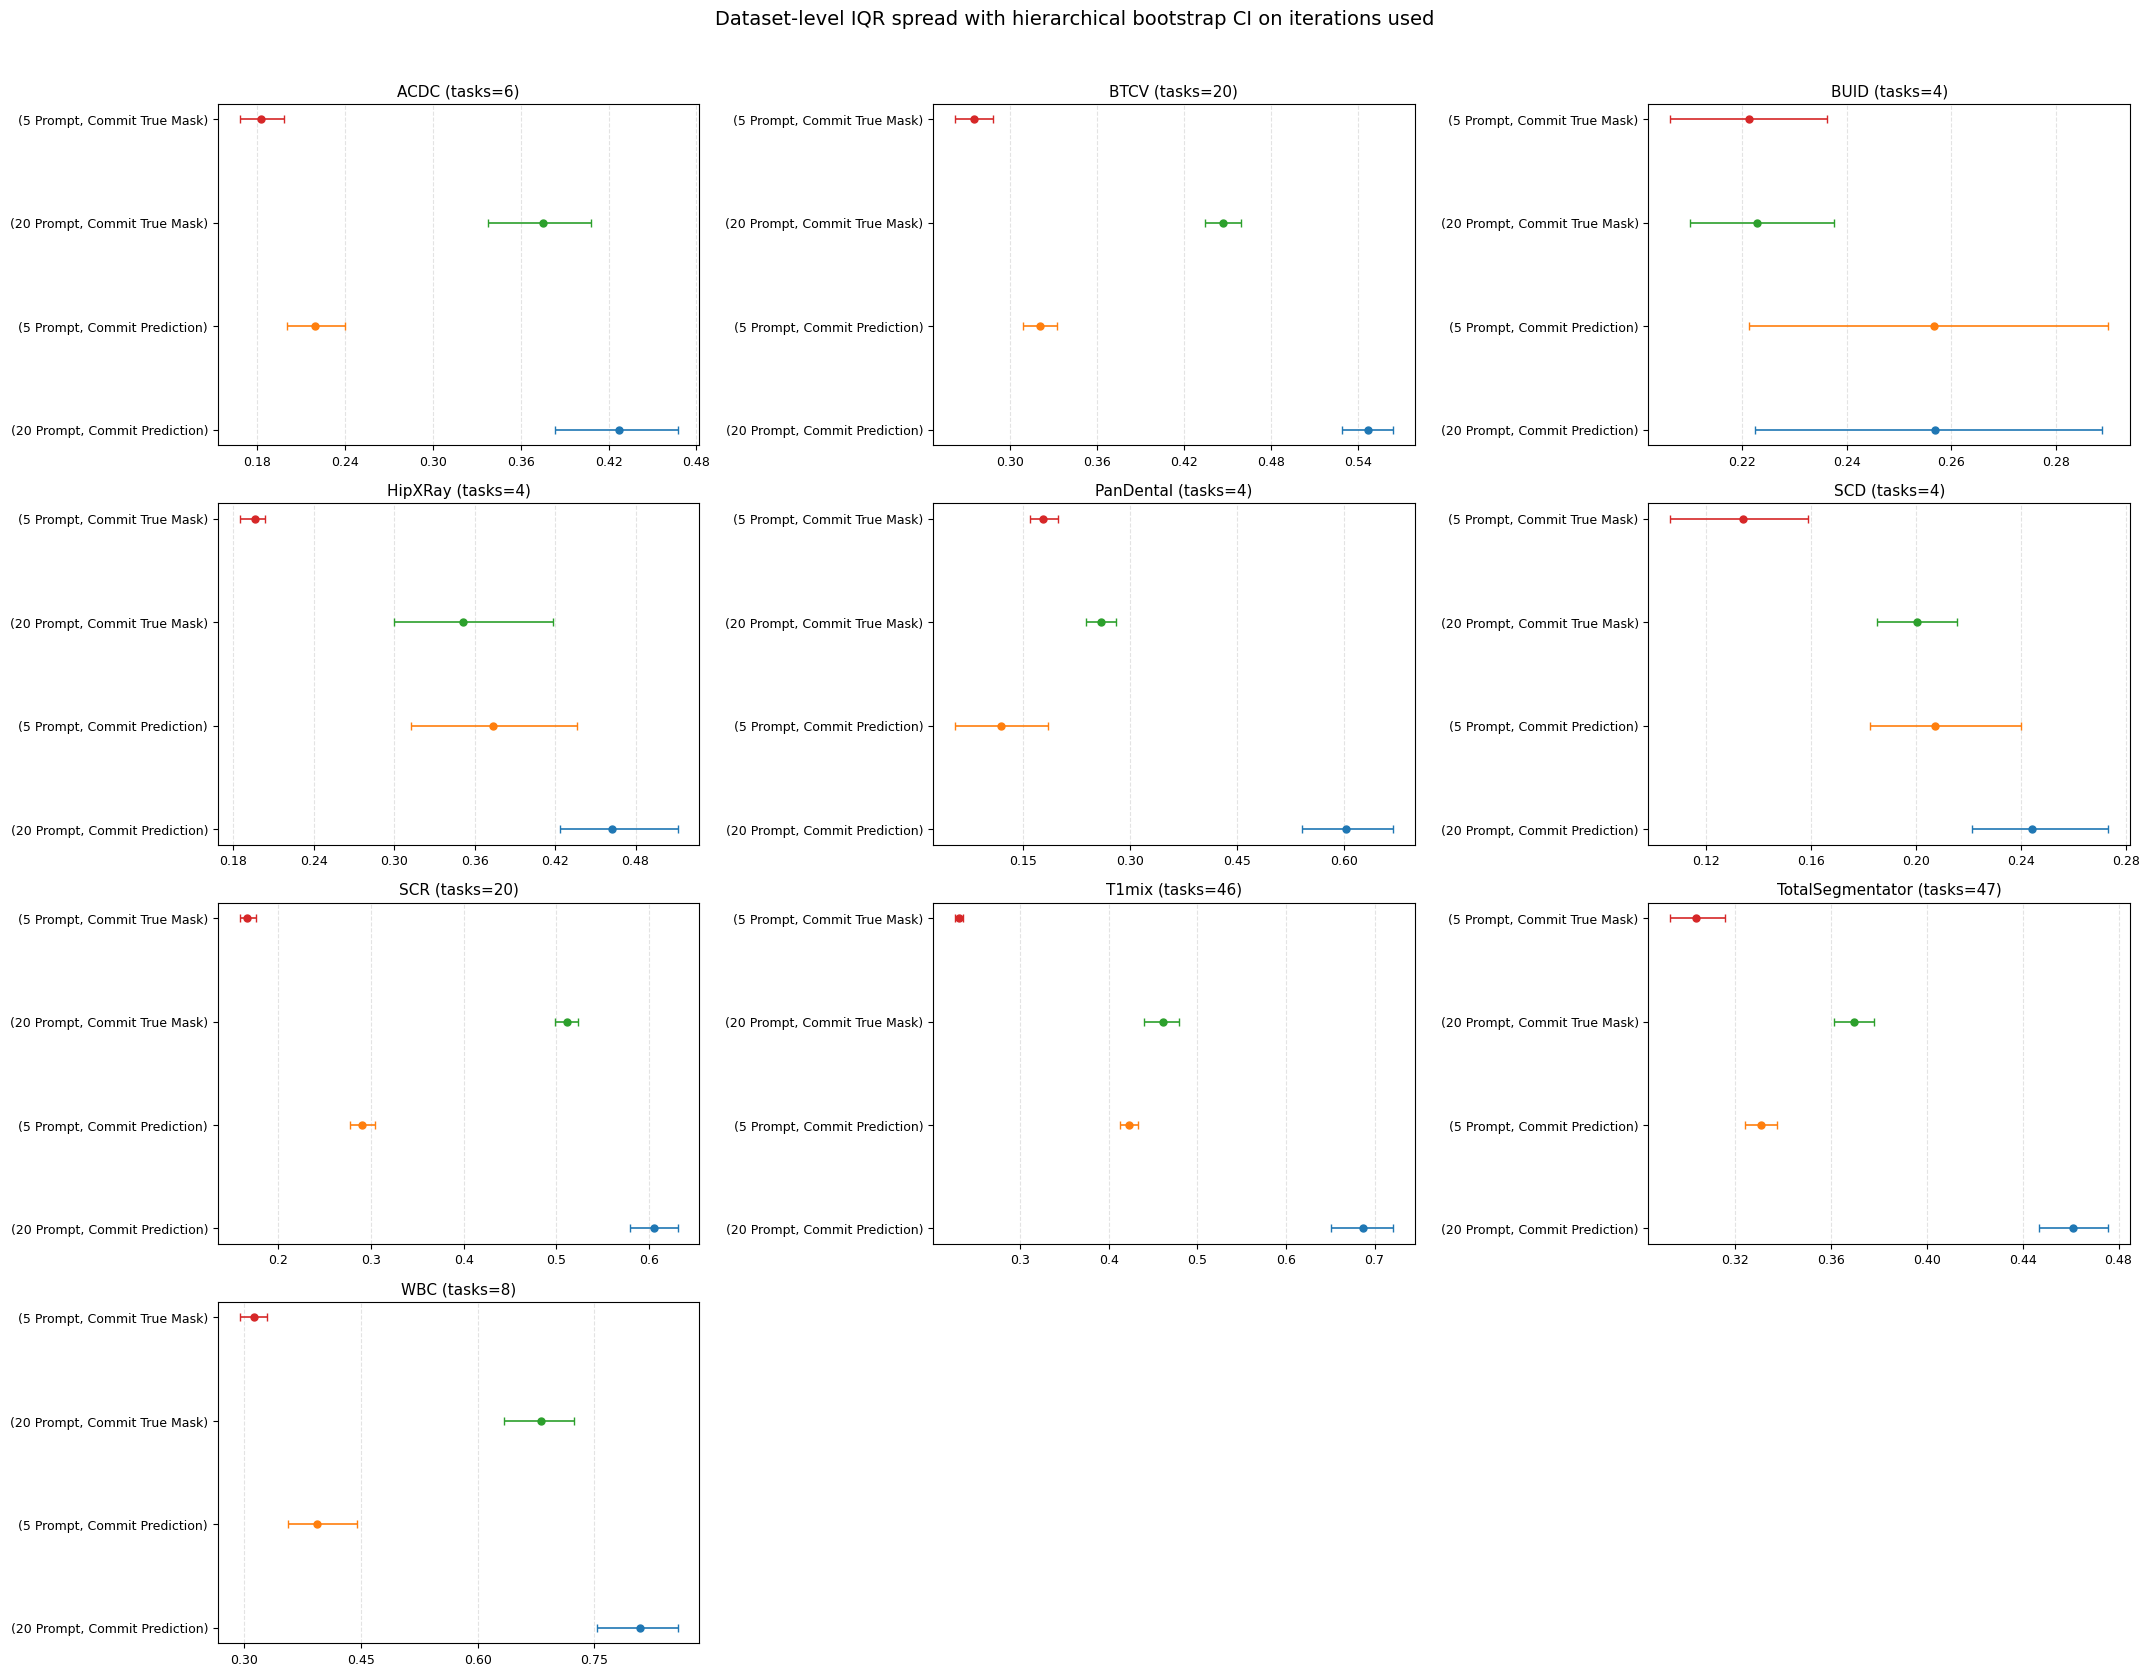

=== initial_dice ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,initial_dice,iqr,IQR,0.040909,0.038469,0.043235,6,60
1,ACDC,pretrained_baseline5,initial_dice,iqr,IQR,0.044240,0.041711,0.046755,6,60
2,ACDC,pretrained_baseline5_gt,initial_dice,iqr,IQR,0.040041,0.037657,0.042260,6,60
3,ACDC,pretrained_baseline_gt,initial_dice,iqr,IQR,0.040041,0.037657,0.042260,6,60
4,BTCV,pretrained_baseline,initial_dice,iqr,IQR,0.047823,0.046173,0.049530,20,200
5,BTCV,pretrained_baseline5,initial_dice,iqr,IQR,0.050130,0.048364,0.052044,20,200
6,BTCV,pretrained_baseline5_gt,initial_dice,iqr,IQR,0.042589,0.040897,0.044070,20,200
7,BTCV,pretrained_baseline_gt,initial_dice,iqr,IQR,0.042589,0.040897,0.044070,20,200
8,BUID,pretrained_baseline,initial_dice,iqr,IQR,0.066158,0.060097,0.074523,4,40
9,BUID,pretrained_baseline5,initial_dice,iqr,IQR,0.066006,0.059419,0.074036,4,40


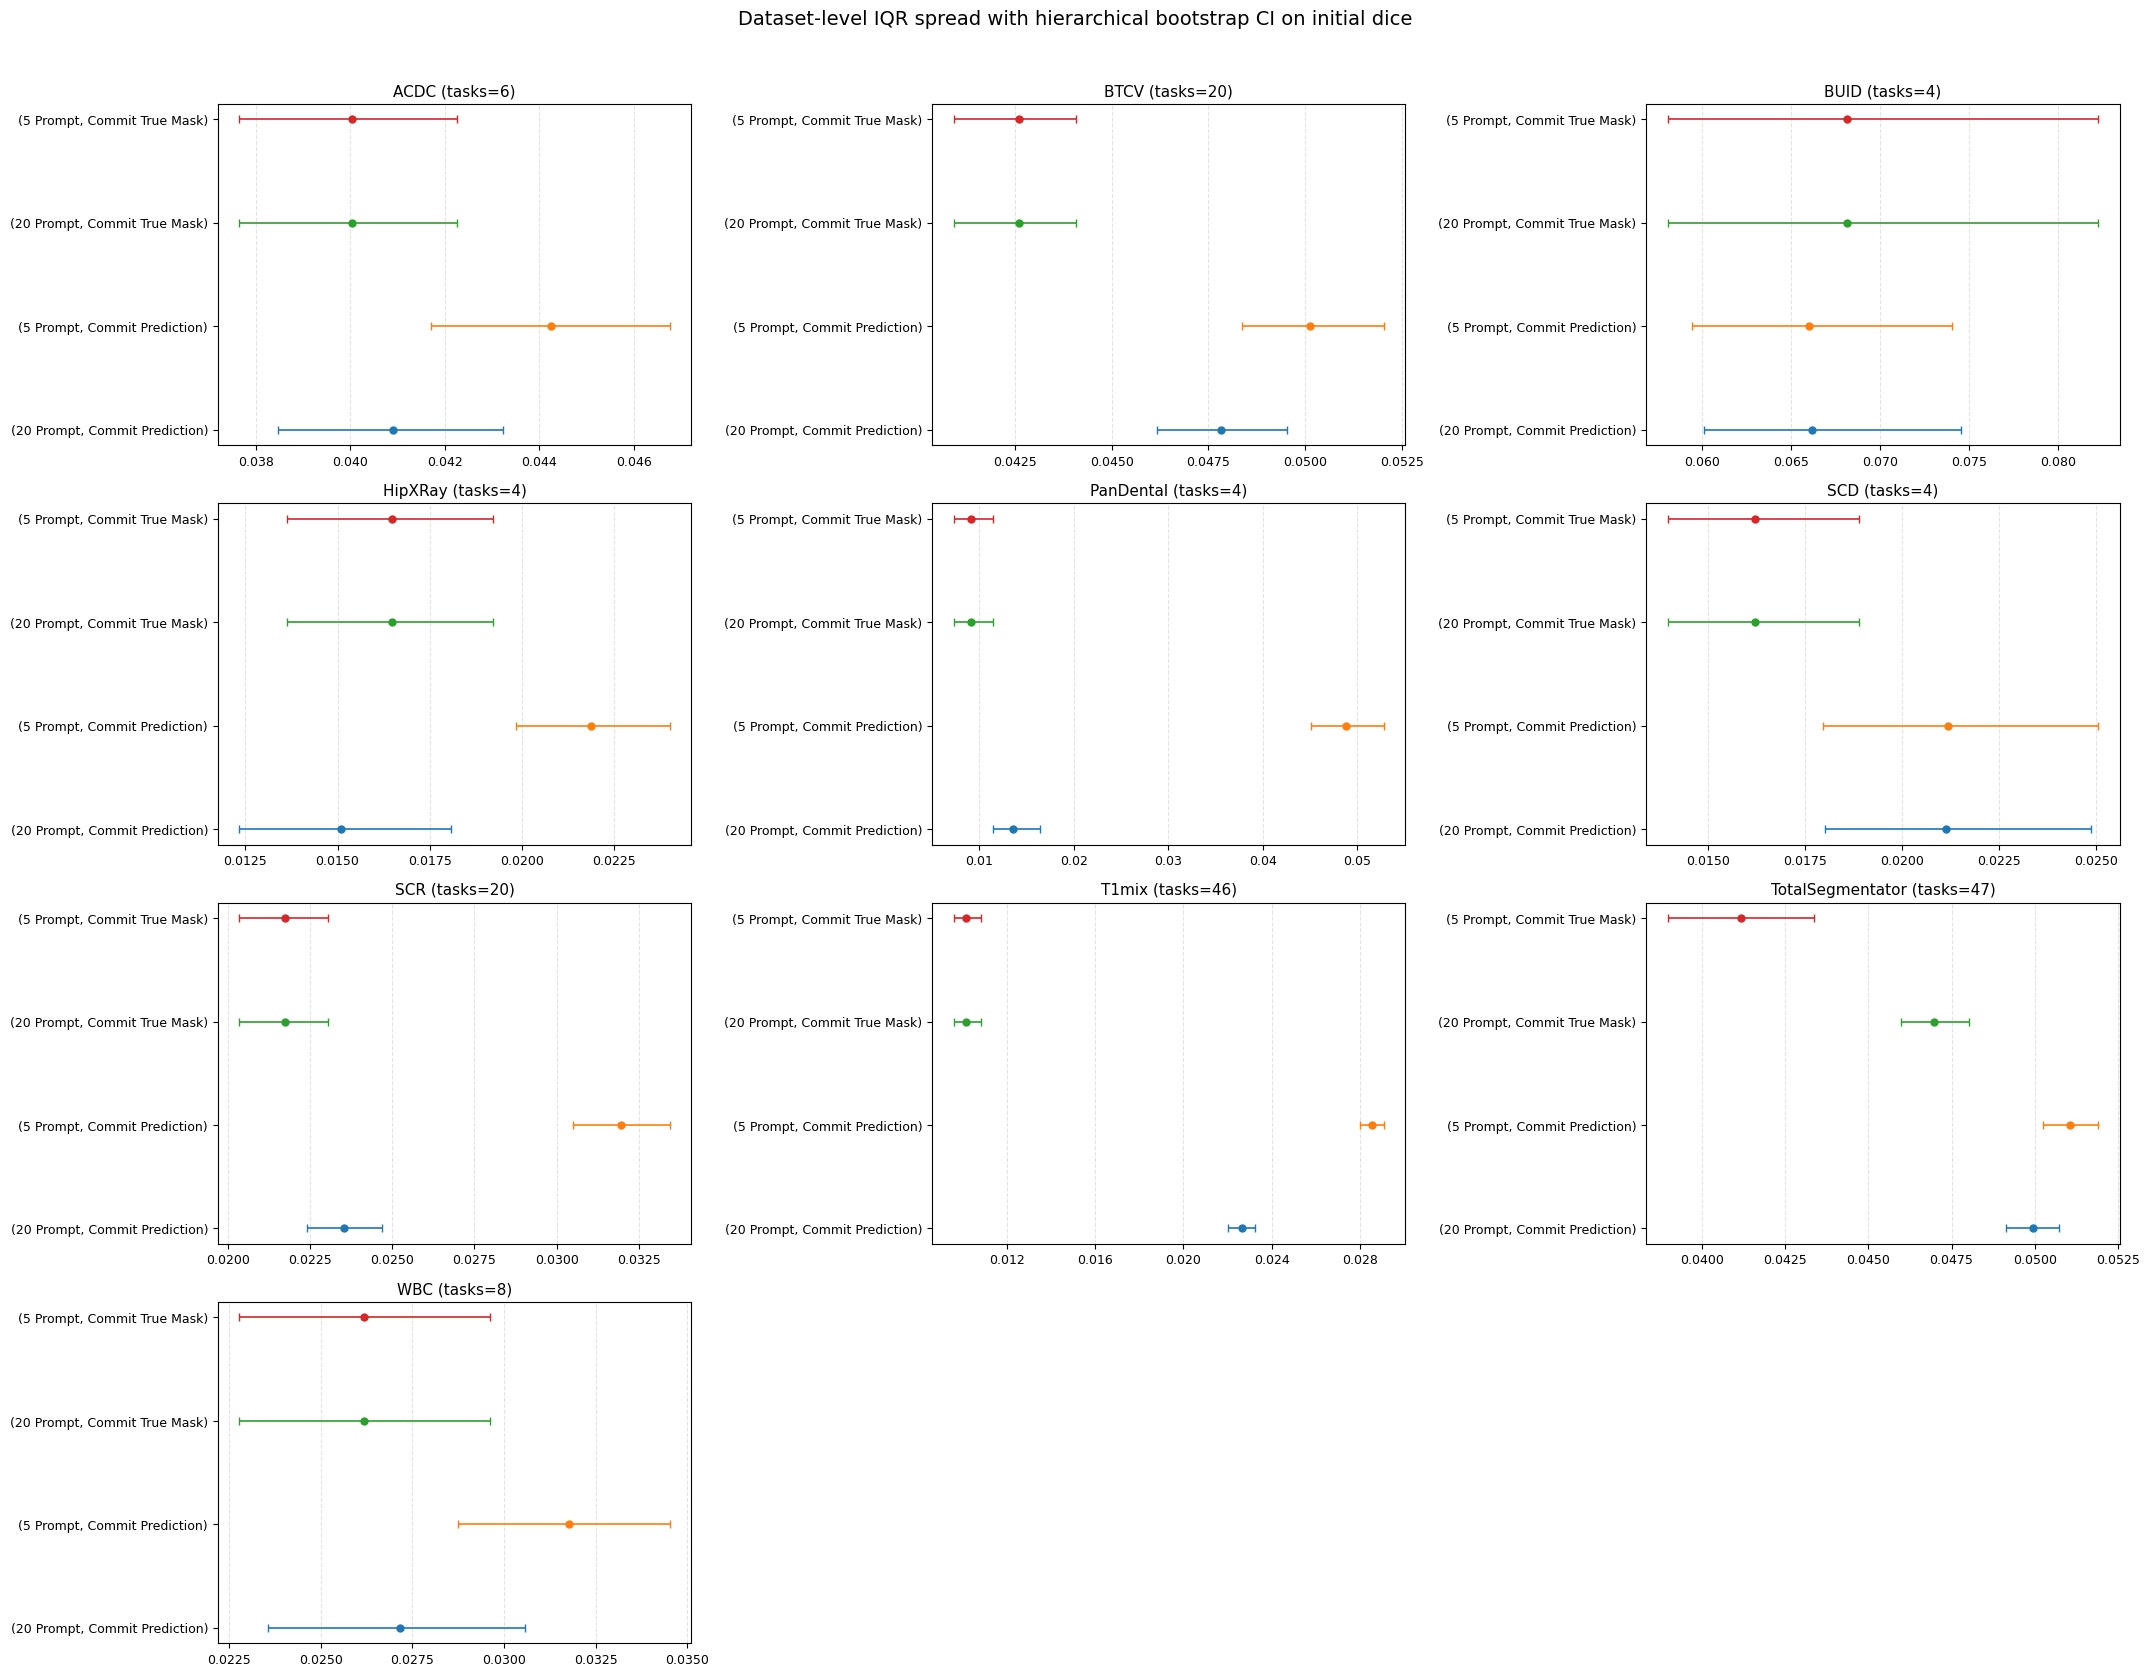

=== final_dice ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,final_dice,iqr,IQR,0.003277,0.002671,0.003958,6,60
1,ACDC,pretrained_baseline5,final_dice,iqr,IQR,0.013827,0.012745,0.015060,6,60
2,ACDC,pretrained_baseline5_gt,final_dice,iqr,IQR,0.010049,0.009306,0.010767,6,60
3,ACDC,pretrained_baseline_gt,final_dice,iqr,IQR,0.003199,0.002515,0.003949,6,60
4,BTCV,pretrained_baseline,final_dice,iqr,IQR,0.004257,0.004156,0.004363,20,200
5,BTCV,pretrained_baseline5,final_dice,iqr,IQR,0.016659,0.015908,0.017410,20,200
6,BTCV,pretrained_baseline5_gt,final_dice,iqr,IQR,0.011957,0.011411,0.012509,20,200
7,BTCV,pretrained_baseline_gt,final_dice,iqr,IQR,0.003466,0.003403,0.003534,20,200
8,BUID,pretrained_baseline,final_dice,iqr,IQR,0.001374,0.001269,0.001487,4,40
9,BUID,pretrained_baseline5,final_dice,iqr,IQR,0.007046,0.006056,0.008057,4,40


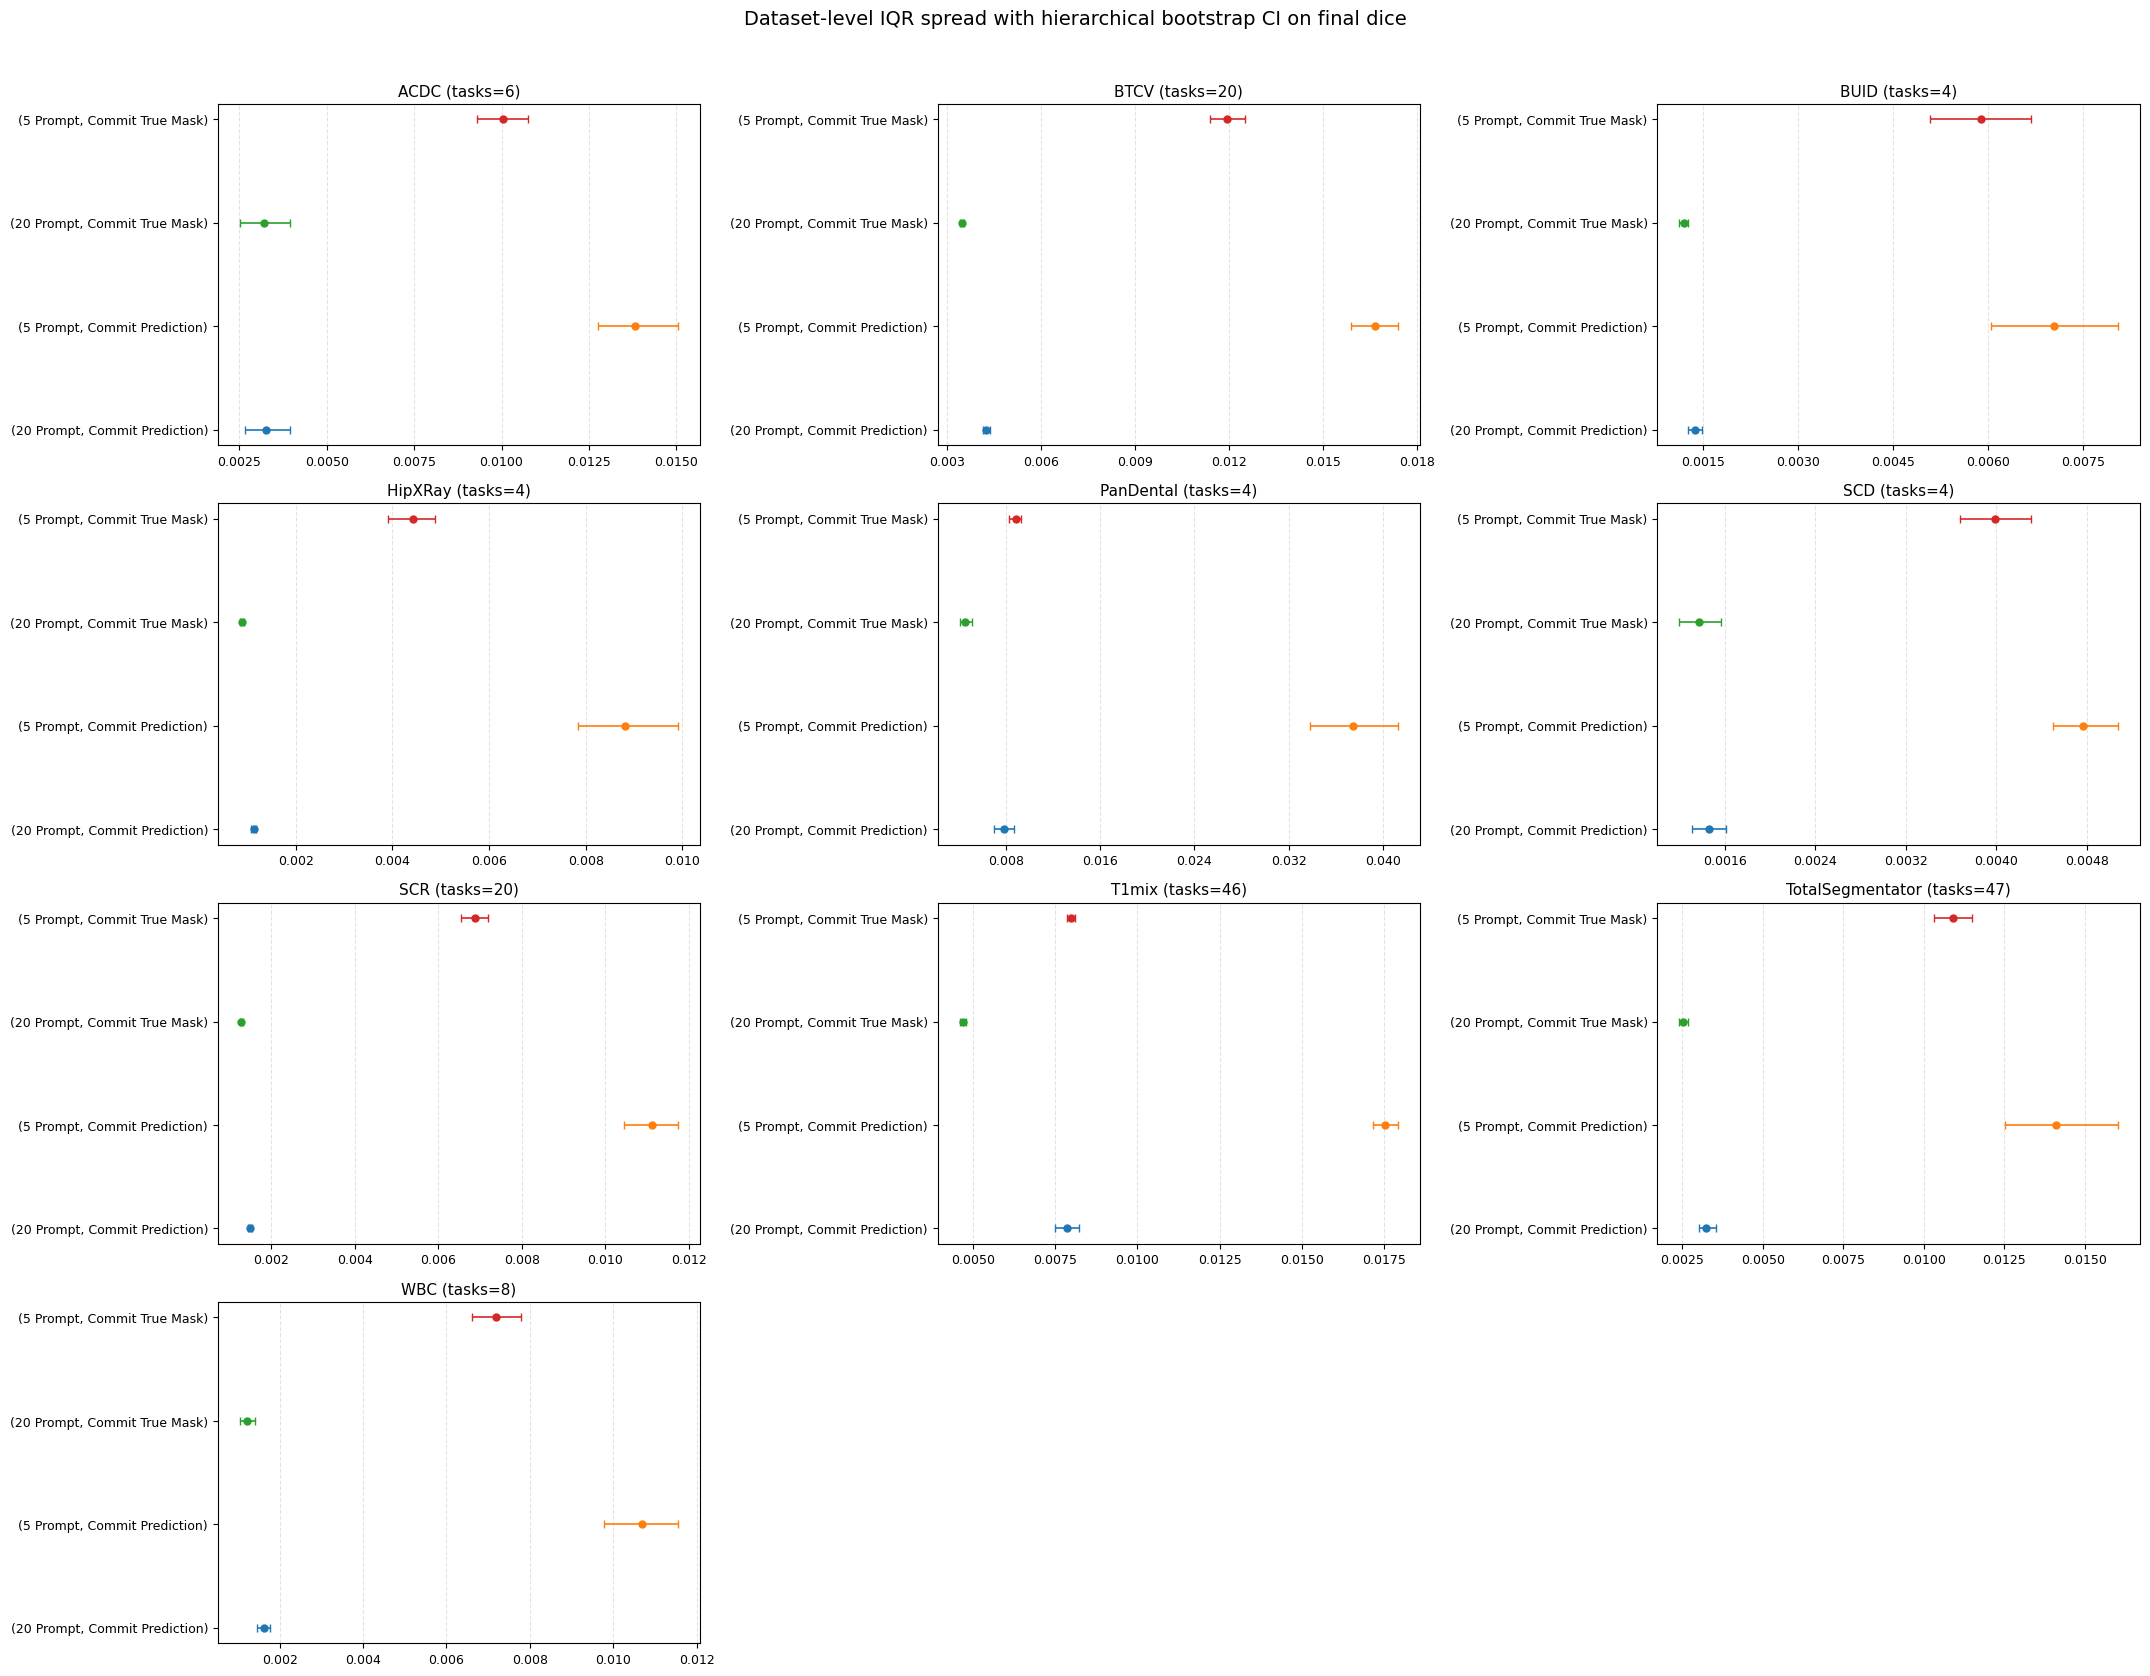

=== dice_at_goal ===


,family,ablation,metric,spread_mode,spread_label,mean,ci_lo,ci_hi,n_tasks,n_subsets
0,ACDC,pretrained_baseline,dice_at_goal,iqr,IQR,0.006201,0.005644,0.006788,6,60
1,ACDC,pretrained_baseline5,dice_at_goal,iqr,IQR,0.014906,0.013847,0.016172,6,60
2,ACDC,pretrained_baseline5_gt,dice_at_goal,iqr,IQR,0.011344,0.010627,0.012038,6,60
3,ACDC,pretrained_baseline_gt,dice_at_goal,iqr,IQR,0.005896,0.005264,0.006556,6,60
4,BTCV,pretrained_baseline,dice_at_goal,iqr,IQR,0.011516,0.011251,0.011759,20,200
5,BTCV,pretrained_baseline5,dice_at_goal,iqr,IQR,0.018825,0.018208,0.019515,20,200
6,BTCV,pretrained_baseline5_gt,dice_at_goal,iqr,IQR,0.014136,0.013396,0.014863,20,200
7,BTCV,pretrained_baseline_gt,dice_at_goal,iqr,IQR,0.009718,0.009552,0.009890,20,200
8,BUID,pretrained_baseline,dice_at_goal,iqr,IQR,0.016541,0.015844,0.017330,4,40
9,BUID,pretrained_baseline5,dice_at_goal,iqr,IQR,0.017235,0.016517,0.017890,4,40


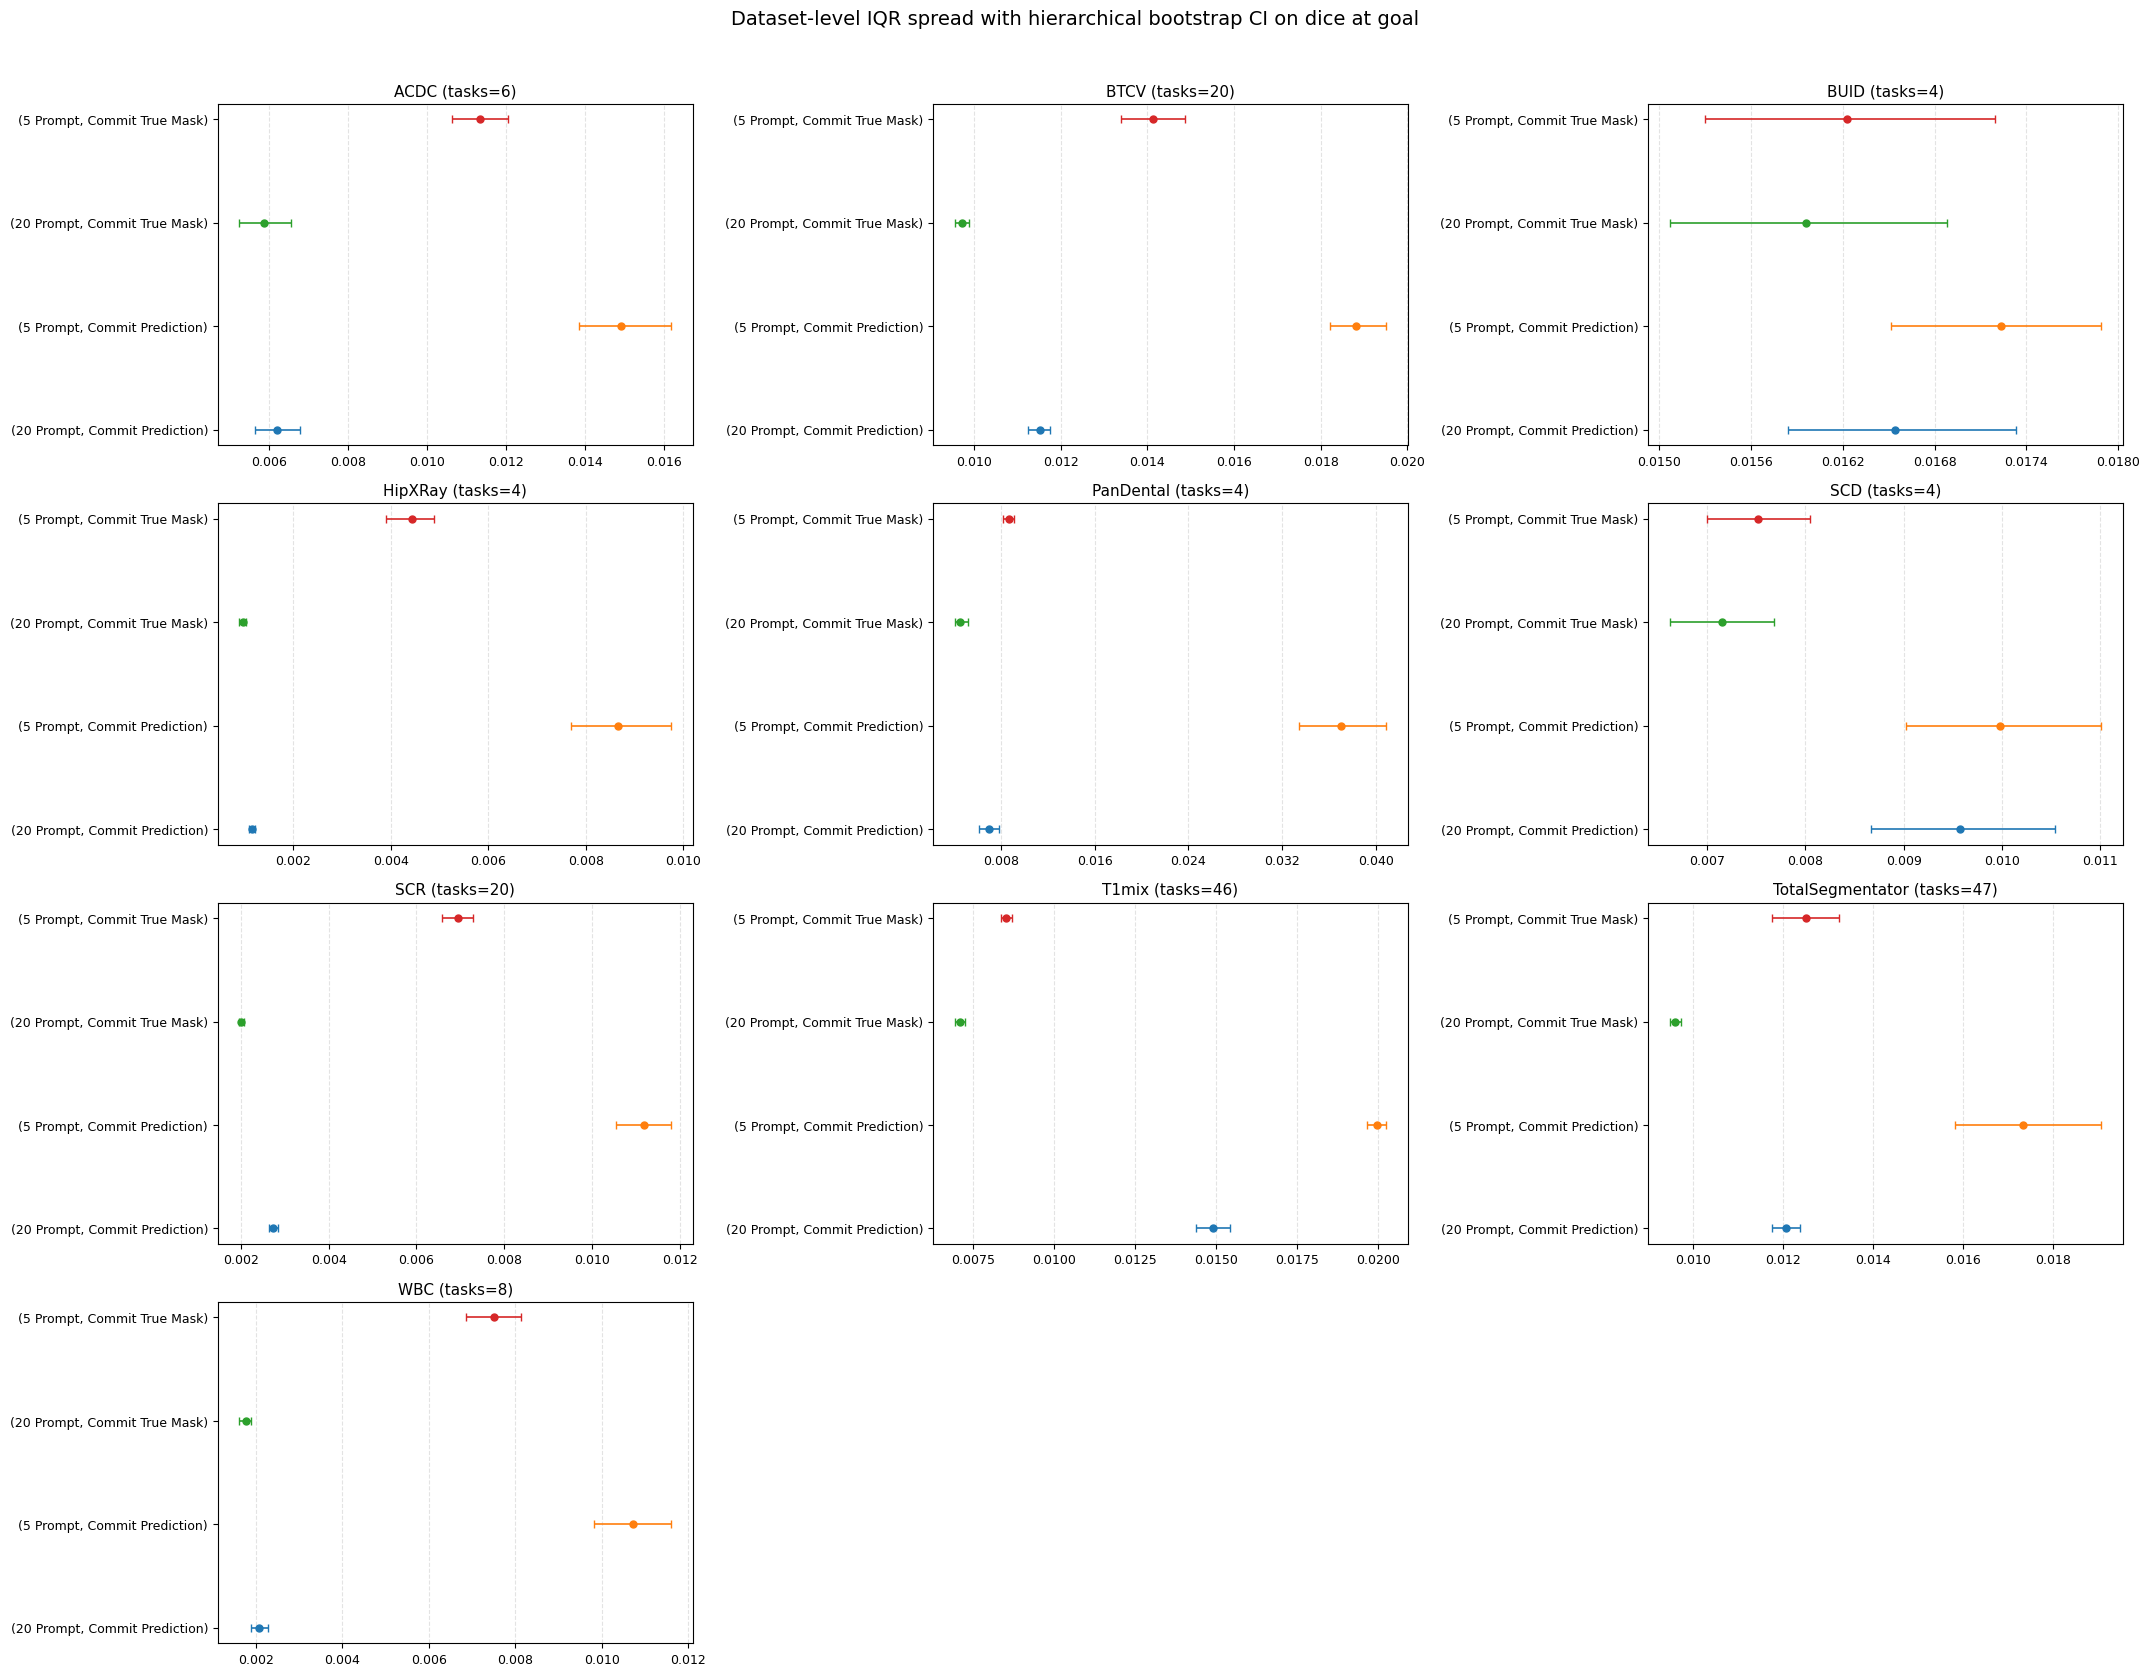

In [22]:
for metric in METRICS:
    print(f"=== {metric} ===")
    display(metric_to_summary.get(metric, pd.DataFrame()))
    plot_forest_grid_for_metric(metric, metric_to_summary.get(metric, pd.DataFrame()))


In [20]:
# Optional: save summary table for downstream analysis.
if not summary_all.empty:
    out_csv = REPO_ROOT / "figures" / "random_v2_spread_hierci" / f"random_v2_spread_summary_{SPREAD_MODE}.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    summary_all.to_csv(out_csv, index=False)
    print(f"Wrote: {out_csv}")


Wrote: /data/ddmg/mvseg-ordering/figures/random_v2_spread_hierci/random_v2_spread_summary_iqr.csv
